# Naive Bayes TF IDF— MBTI Binary Dimensions
This notebook trains four binary Multinomial Naive Bayes classifiers (one per MBTI dimension).
Adjust file paths if your working directory differs from the repository root.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import f1_score



In [13]:
# --- STEP 1: Load the CSV ---
print("🔄 Loading data from CSV...")

# 1. Find the file (Teammate-Safe)
current_dir = Path.cwd()
csv_path = None

# Search for 'preprocessed_data.csv' in current and parent folders
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break

# Check if csv_path was found
if csv_path is None:
    raise FileNotFoundError(f"❌ Could not find 'preprocessed_data.csv' in current directory or parent folders")

print(f"📂 Found CSV at: {csv_path}")

🔄 Loading data from CSV...
📂 Found CSV at: c:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv


In [14]:
# 2. Read the CSV
df = pd.read_csv(csv_path)

# --- THE CHANGE: Explicitly selecting columns based on your snippet ---
# Your snippet showed: type, posts, no. of. words, type_encoded
print(f"   Columns found: {df.columns.tolist()}")

text_col = 'posts' 
target_col = 'type'

# Sanity check to ensure these columns exist before proceeding
if text_col not in df.columns or target_col not in df.columns:
    raise ValueError(f"❌ Error: Expected columns '{text_col}' and '{target_col}' but found {df.columns.tolist()}")

print(f"   Using columns: Text='{text_col}', Target='{target_col}'")

# Remove rows where text or type is missing
df = df.dropna(subset=[text_col, target_col]) 

# --- STEP 2: Vectorization ---
print("\n🧮 Vectorizing text (TF-IDF)... This might take a minute...")
# We keep max_features=5000 for speed
# Note: 'eostokendot' and other tokens will be handled automatically by TF-IDF (low weight if common)
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

X = tfidf.fit_transform(df[text_col])
y = df[target_col].values # This contains strings like "INFJ", "ENTP"

print(f"✅ Data Ready! Features shape: {X.shape}")

   Columns found: ['type', 'posts', 'num_posts', 'no. of. words', 'type_encoded']
   Using columns: Text='posts', Target='type'

🧮 Vectorizing text (TF-IDF)... This might take a minute...
✅ Data Ready! Features shape: (8462, 2000)



🚀 Starting Naive Bayes Training...

--- Processing I vs E ---
   Train Accuracy: 78.82%
   Test Accuracy:  72.76%
   Difference:     6.06%
   ⚠️  Possible overfitting detected!
📊 Macro F1-Score: 0.7249
   Confusion Matrix:
[[ 822  484]
 [ 228 1080]]

--- Processing N vs S ---
   Train Accuracy: 79.66%
   Test Accuracy:  74.81%
   Difference:     4.84%
📊 Macro F1-Score: 0.7436
   Confusion Matrix:
[[ 896  590]
 [ 144 1284]]

--- Processing T vs F ---
   Train Accuracy: 78.92%
   Test Accuracy:  74.81%
   Difference:     4.12%
📊 Macro F1-Score: 0.7464
   Confusion Matrix:
[[607 304]
 [155 756]]

--- Processing J vs P ---
   Train Accuracy: 74.32%
   Test Accuracy:  64.54%
   Difference:     9.78%
   ⚠️  Possible overfitting detected!
📊 Macro F1-Score: 0.6449
   Confusion Matrix:
[[696 320]
 [403 620]]

📊 Generating Bar Graph...


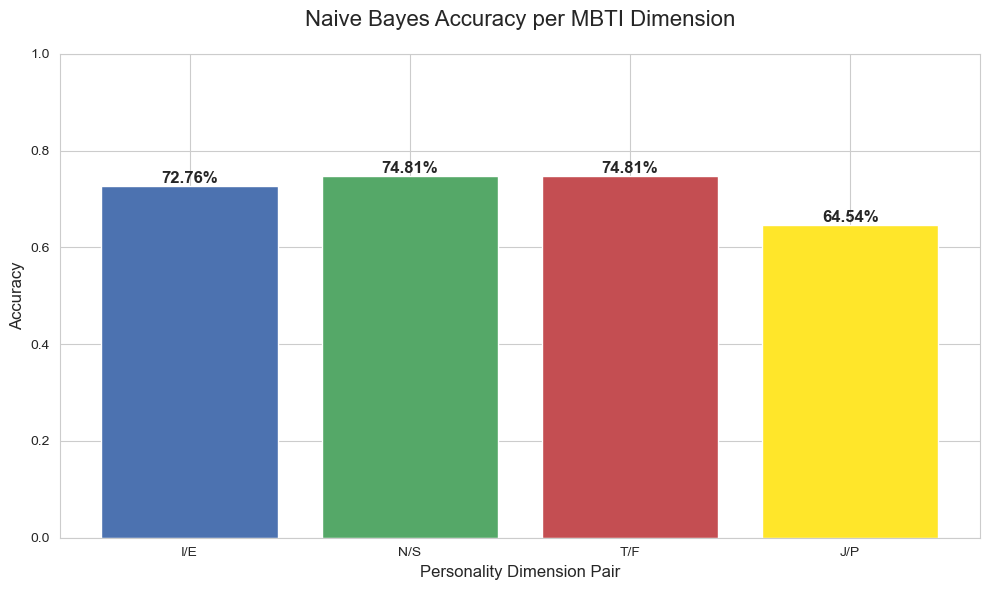


📈 Total Sum of Accuracies: 2.8692
📊 Average Accuracy: 71.73%
average f1 score: 0.7150


In [23]:
# --- STEP 3: Train the 4 Binary Models & Plot ---
print("\n🚀 Starting Naive Bayes Training...")

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
f1_scores = []

# Set a nice style for the plots
sns.set_style("whitegrid")

for trait1, trait2 in dimensions:
    print(f"\n--- Processing {trait1} vs {trait2} ---")
    
    # Logic: If the label contains the second letter (e.g. 'E'), it's a 1. Else 0.
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # Upsampling (Crucial for Naive Bayes)
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y_binary)
    
    # Split Data (Using your specific test_size=0.18)
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=0.20, random_state=42
    )
    
    # Train with alpha tuning to prevent overfitting
    # Alpha adds smoothing - higher values = less overfitting but potentially lower accuracy
    clf = MultinomialNB(alpha=5.0)  # Default is 1.0, try values like 0.5, 1.0, 2.0
    clf.fit(X_train, y_train)
    
    # Evaluate on BOTH train and test to detect overfitting
    train_preds = clf.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    
    test_preds = clf.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)

    current_f1 = f1_score(y_test, test_preds, average='macro')
    f1_scores.append(current_f1) 
    
    conf_mat = confusion_matrix(y_test, test_preds)
    
    results[f"{trait1}/{trait2}"] = test_acc
    
    print(f"   Train Accuracy: {train_acc:.2%}")
    print(f"   Test Accuracy:  {test_acc:.2%}")
    print(f"   Difference:     {(train_acc - test_acc):.2%}")
    if train_acc - test_acc > 0.05:
        print(f"   ⚠️  Possible overfitting detected!")
    print(f"📊 Macro F1-Score: {current_f1:.4f}")
    print(f"   Confusion Matrix:\n{conf_mat}")

# --- PLOTTING THE RESULTS ---
print("\n📊 Generating Bar Graph...")

plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Create bars
bars = plt.bar(keys, values, color=['#4c72b0', '#55a868', '#c44e52', "#ffe62a"])

# Add title and labels
plt.title('Naive Bayes Accuracy per MBTI Dimension', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.0) # Scale y-axis from 0 to 100%

# Add the percentage numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2%}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- SUM OF ACCURACIES ---
total_accuracy = sum(results.values())
avg_accuracy = total_accuracy / len(results)
avg_f1 = sum(f1_scores) / len(f1_scores)
print(f"\n📈 Total Sum of Accuracies: {total_accuracy:.4f}")
print(f"📊 Average Accuracy: {avg_accuracy:.2%}")
print(f"average f1 score: {avg_f1:.4f}")

In [16]:
# --- Final Summary ---
print("\n" + "="*30)
print("FINAL RESULTS")
print("="*30)
for pair, score in results.items():
    print(f"{pair}: {score:.2%}")


FINAL RESULTS
I/E: 69.70%
N/S: 73.54%
T/F: 73.77%
J/P: 62.38%


volgende implementaties zijn miss wel leuk voor in het verslag

In [22]:
#unbalanced version
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- STEP 1: Load Data 
print("🔄 Loading data...")
current_dir = Path.cwd()
csv_path = None
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break
if not csv_path:
    # Fallback absolute path
    csv_path = Path(r"C:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['posts', 'type'])

# --- STEP 2: Vectorization ---
print("🧮 Vectorizing text (TF-IDF)...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X = tfidf.fit_transform(df['posts'])
y_full = df['type'].values

# Keep indices consistent for reconstruction
indices = np.arange(X.shape[0])
X_train_idx, X_test_idx, y_train_idx, y_test_idx, idx_train, idx_test = train_test_split(
    X, y_full, indices, test_size=0.2, random_state=42
)

# ========================================================
# PART A: 4 SEPARATE BINARY MODELS (NO UPSAMPLING)
# ========================================================
from sklearn.metrics import f1_score # Ensure this is imported

print("\n" + "="*40)
print("PART A: 4 Separate Binary Models (UNBALANCED)")
print("="*40)

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
dim_predictions = {} 
f1_scores = [] # List to store F1s for the average

for trait1, trait2 in dimensions:
    print(f"\n--- Dimension: {trait1} vs {trait2} ---")
    
    # 1. Prepare Targets for WHOLE dataset first
    y_binary = np.array([1 if trait2 in label else 0 for label in y_full])
    
    # 2. Select Train/Test using the fixed indices
    # (We DO NOT use RandomOverSampler here)
    X_train = X[idx_train]
    y_train = y_binary[idx_train]
    y_test_dim = y_binary[idx_test]
    X_test = X[idx_test]
    
    # 3. Train
    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    
    # 4. Detailed Results
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test_dim, preds)
    
    # --- ADDED: F1 Score Calculation ---
    # We use 'macro' to punish the model if it ignores the minority class
    f1 = f1_score(y_test_dim, preds, average='macro')
    f1_scores.append(f1)
    
    cm = confusion_matrix(y_test_dim, preds)
    
    print(f"   Accuracy:       {acc:.2%}")
    print(f"   Macro F1-Score: {f1:.4f}") # <--- Now printed
    print(f"   Confusion Matrix:\n{cm}")
    print(f"   (0={trait1}, 1={trait2})")
    
    # Store for full reconstruction: 0->trait1, 1->trait2
    dim_predictions[f"{trait1}{trait2}"] = [trait2 if p == 1 else trait1 for p in preds]

# Reconstruct Full 16-Type Prediction
print("\n--- Reconstructing Full Types from Binary Models ---")
reconstructed_preds = []
for i in range(len(idx_test)):
    full_type = (dim_predictions['IE'][i] + dim_predictions['NS'][i] + 
                 dim_predictions['TF'][i] + dim_predictions['JP'][i])
    reconstructed_preds.append(full_type)

real_types = y_full[idx_test]
binary_full_acc = accuracy_score(real_types, reconstructed_preds)

print(f"Combined Accuracy (4 Models -> 1 Type): {binary_full_acc:.2%}")
print(f"Average Macro F1 across 4 dimensions:   {sum(f1_scores)/len(f1_scores):.4f}")

# ========================================================
# PART B: 1 MULTI-CLASS MODEL (NO UPSAMPLING)
# ========================================================
print("\n" + "="*40)
print("PART B: One Multi-Class Model (UNBALANCED)")
print("="*40)

# Train on full 16 types directly
clf_multi = MultinomialNB()
clf_multi.fit(X_train_idx, y_train_idx) # Training on "INTJ", "ENTP", etc.

preds_multi = clf_multi.predict(X_test_idx)
multi_acc = accuracy_score(y_test_idx, preds_multi)

print(f"Multi-Class Accuracy: {multi_acc:.2%}")
print("\nDetailed Classification Report:")
# This shows precision/recall for every single personality type
print(classification_report(y_test_idx, preds_multi, zero_division=0))

🔄 Loading data...
🧮 Vectorizing text (TF-IDF)...

PART A: 4 Separate Binary Models (UNBALANCED)

--- Dimension: I vs E ---
   Accuracy:       76.43%
   Macro F1-Score: 0.4332
   Confusion Matrix:
[[1294    0]
 [ 399    0]]
   (0=I, 1=E)

--- Dimension: N vs S ---
   Accuracy:       86.95%
   Macro F1-Score: 0.4651
   Confusion Matrix:
[[1472    0]
 [ 221    0]]
   (0=N, 1=S)

--- Dimension: T vs F ---
   Accuracy:       71.23%
   Macro F1-Score: 0.6816
   Confusion Matrix:
[[340 419]
 [ 68 866]]
   (0=T, 1=F)

--- Dimension: J vs P ---
   Accuracy:       61.08%
   Macro F1-Score: 0.3806
   Confusion Matrix:
[[   1  658]
 [   1 1033]]
   (0=J, 1=P)

--- Reconstructing Full Types from Binary Models ---
Combined Accuracy (4 Models -> 1 Type): 28.06%
Average Macro F1 across 4 dimensions:   0.4901

PART B: One Multi-Class Model (UNBALANCED)
Multi-Class Accuracy: 23.21%

Detailed Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.00      0.00  

In [18]:
# balanced version
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler

# --- STEP 1: Load Data (Teammate-Safe) ---
print("🔄 Loading data...")
current_dir = Path.cwd()
csv_path = None
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break
if not csv_path:
    csv_path = Path(r"C:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['posts', 'type'])

# --- STEP 2: Vectorization ---
print("🧮 Vectorizing text (TF-IDF)...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X = tfidf.fit_transform(df['posts'])
y_full = df['type'].values

# Keep indices consistent
indices = np.arange(X.shape[0])
X_train_idx, X_test_idx, y_train_idx, y_test_idx, idx_train, idx_test = train_test_split(
    X, y_full, indices, test_size=0.2, random_state=42
)

# ========================================================
# PART A: 4 SEPARATE BINARY MODELS (WITH UPSAMPLING)
# ========================================================
print("\n" + "="*40)
print("PART A: 4 Separate Binary Models (UPSAMPLED)")
print("="*40)

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
dim_predictions = {} 

for trait1, trait2 in dimensions:
    print(f"\n--- Dimension: {trait1} vs {trait2} ---")
    
    y_binary = np.array([1 if trait2 in label else 0 for label in y_full])
    
    # Select Train set
    X_train = X[idx_train]
    y_train = y_binary[idx_train]
    y_test_dim = y_binary[idx_test]
    X_test = X[idx_test]
    
    # --- UPSAMPLING APPLIED HERE ---
    ros = RandomOverSampler(random_state=42)
    X_train_up, y_train_up = ros.fit_resample(X_train, y_train)
    # -------------------------------
    
    # Train
    clf = MultinomialNB()
    clf.fit(X_train_up, y_train_up)
    
    # Detailed Results
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test_dim, preds)
    cm = confusion_matrix(y_test_dim, preds)
    
    print(f"   Accuracy: {acc:.2%}")
    print(f"   Confusion Matrix:\n{cm}")
    print(f"   (0={trait1}, 1={trait2})")
    
    dim_predictions[f"{trait1}{trait2}"] = [trait2 if p == 1 else trait1 for p in preds]

# Reconstruct Full 16-Type Prediction
print("\n--- Reconstructing Full Types from Binary Models ---")
reconstructed_preds = []
for i in range(len(idx_test)):
    full_type = (dim_predictions['IE'][i] + dim_predictions['NS'][i] + 
                 dim_predictions['TF'][i] + dim_predictions['JP'][i])
    reconstructed_preds.append(full_type)

real_types = y_full[idx_test]
binary_full_acc = accuracy_score(real_types, reconstructed_preds)
print(f"Combined Accuracy (4 Models -> 1 Type): {binary_full_acc:.2%}")

# ========================================================
# PART B: 1 MULTI-CLASS MODEL (WITH UPSAMPLING)
# ========================================================
print("\n" + "="*40)
print("PART B: One Multi-Class Model (UPSAMPLED)")
print("="*40)

# --- UPSAMPLING APPLIED HERE ---
ros = RandomOverSampler(random_state=42)
X_train_multi_up, y_train_multi_up = ros.fit_resample(X_train_idx, y_train_idx)
# -------------------------------

clf_multi = MultinomialNB()
clf_multi.fit(X_train_multi_up, y_train_multi_up)

preds_multi = clf_multi.predict(X_test_idx)
multi_acc = accuracy_score(y_test_idx, preds_multi)

print(f"Multi-Class Accuracy: {multi_acc:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_idx, preds_multi, zero_division=0))

🔄 Loading data...
🧮 Vectorizing text (TF-IDF)...

PART A: 4 Separate Binary Models (UPSAMPLED)

--- Dimension: I vs E ---
   Accuracy: 68.64%
   Confusion Matrix:
[[939 355]
 [176 223]]
   (0=I, 1=E)

--- Dimension: N vs S ---
   Accuracy: 73.95%
   Confusion Matrix:
[[1138  334]
 [ 107  114]]
   (0=N, 1=S)

--- Dimension: T vs F ---
   Accuracy: 75.31%
   Confusion Matrix:
[[530 229]
 [189 745]]
   (0=T, 1=F)

--- Dimension: J vs P ---
   Accuracy: 59.72%
   Confusion Matrix:
[[368 291]
 [391 643]]
   (0=J, 1=P)

--- Reconstructing Full Types from Binary Models ---
Combined Accuracy (4 Models -> 1 Type): 24.57%

PART B: One Multi-Class Model (UPSAMPLED)
Multi-Class Accuracy: 28.41%

Detailed Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.03      0.05      0.04        40
        ENFP       0.26      0.27      0.26       145
        ENTJ       0.11      0.20      0.14        45
        ENTP       0.22      0.16      0.18       132
    